In [5]:
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns
import heapq
from collections import defaultdict

prioritized sweeping

In [6]:
STEPS = 100000
GAMMA = 1.0
ALPHA = 0.1
EPSILON = 0.05
N = 5
THETA = 0.01

env = gym.make("Blackjack-v1", sab=False)

eps_greedy = lambda q_vals, eps: np.random.randint(len(q_vals)) if np.random.rand() < eps else np.argmax(q_vals)
def state_to_idx(s): return s[0]-1, s[1]-1, s[2]


#init q(s,a) = 0
q = np.zeros((21, 10, 2, 2)) #21x10x2x2 action-states
m = np.zeros((21, 10, 2, 2, 5)) #21x10x2 states, 2 actions, 4 r/s1_n/s2_n/s3_n/terminal
m_seen = np.zeros((21, 10, 2, 2), dtype=bool) 
seen_sa = []
predecessors = defaultdict(set)
pqueue = []

wins = []

#loop
s, _ = env.reset()
for step in range(STEPS):
    #current state s
    s1, s2, s3 = state_to_idx(s)
    
    #set a
    a = eps_greedy(q[s1, s2, s3], EPSILON)

    #take a, observe r, s'
    s_n, r, term, trunc, info = env.step(a)
    s1_n, s2_n, s3_n = state_to_idx(s_n)

    #store r, s in model
    m[s1, s2, s3, a] = [r, s1_n, s2_n, s3_n, 1.0 if (term or trunc) else 0.0]
    predecessors[(s1_n, s2_n, s3_n)].add((s1, s2, s3, a))
    if not m_seen[s1, s2, s3, a]:
        m_seen[s1, s2, s3, a] = True
        seen_sa.append((s1, s2, s3, a))

    if term or trunc:
        wins.append(r > 0)
        p = abs(r - q[s1, s2, s3, a])
        s_n, _ = env.reset()

    #how different q value is
    else:
        p = abs(r + GAMMA * np.max(q[s1_n, s2_n, s3_n]) - q[s1, s2, s3, a])

    #insert into pqueue if different
    if p > THETA:
        heapq.heappush(pqueue, (-p, s1, s2, s3, a))

    s = s_n

    #loop n times while not empty
    n = 0
    while pqueue and (n < N):

        # pop largest and q update
        _, s1_p, s2_p, s3_p, a_p = heapq.heappop(pqueue)
        r_p, s1_n_p, s2_n_p, s3_n_p, terminal = m[s1_p, s2_p, s3_p, a_p]
        s1_n_p, s2_n_p, s3_n_p = int(s1_n_p), int(s2_n_p), int(s3_n_p)

        if terminal:
            q[s1_p, s2_p, s3_p, a_p] += ALPHA * (r_p - q[s1_p, s2_p, s3_p, a_p])
        else:
            q[s1_p, s2_p, s3_p, a_p] += ALPHA * (r_p + GAMMA * np.max(q[s1_n_p, s2_n_p, s3_n_p]) - q[s1_p, s2_p, s3_p, a_p])

        #look at all leading up to s_p
        for s1_prev, s2_prev, s3_prev, a_prev in predecessors[(s1_p, s2_p, s3_p)]:
            r_prev, s1_next, s2_next, s3_next, terminal_prev = m[s1_prev, s2_prev, s3_prev, a_prev]
            s1_next, s2_next, s3_next = int(s1_next), int(s2_next), int(s3_next)
            if terminal_prev:
                p_prev = abs(r_prev - q[s1_prev, s2_prev, s3_prev, a_prev])
            else:
                p_prev = abs(r_prev + GAMMA * np.max(q[s1_next, s2_next, s3_next]) - q[s1_prev, s2_prev, s3_prev, a_prev])
            
            #if large difference put into pqueue
            if p_prev > THETA:
                heapq.heappush(pqueue, (-p_prev, s1_prev, s2_prev, s3_prev, a_prev))

        n += 1



env.close()


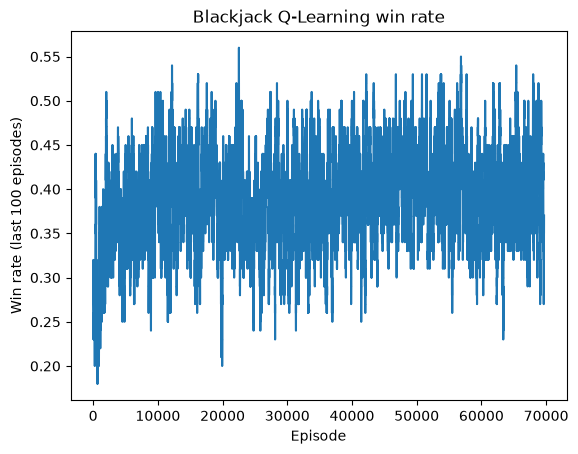

In [7]:
window = 100
win_rate = np.convolve(wins, np.ones(window) / window, mode='valid')

plt.plot(win_rate)
plt.xlabel('Episode')
plt.ylabel(f'Win rate (last {window} episodes)')
plt.title('Blackjack Q-Learning win rate')
plt.show()

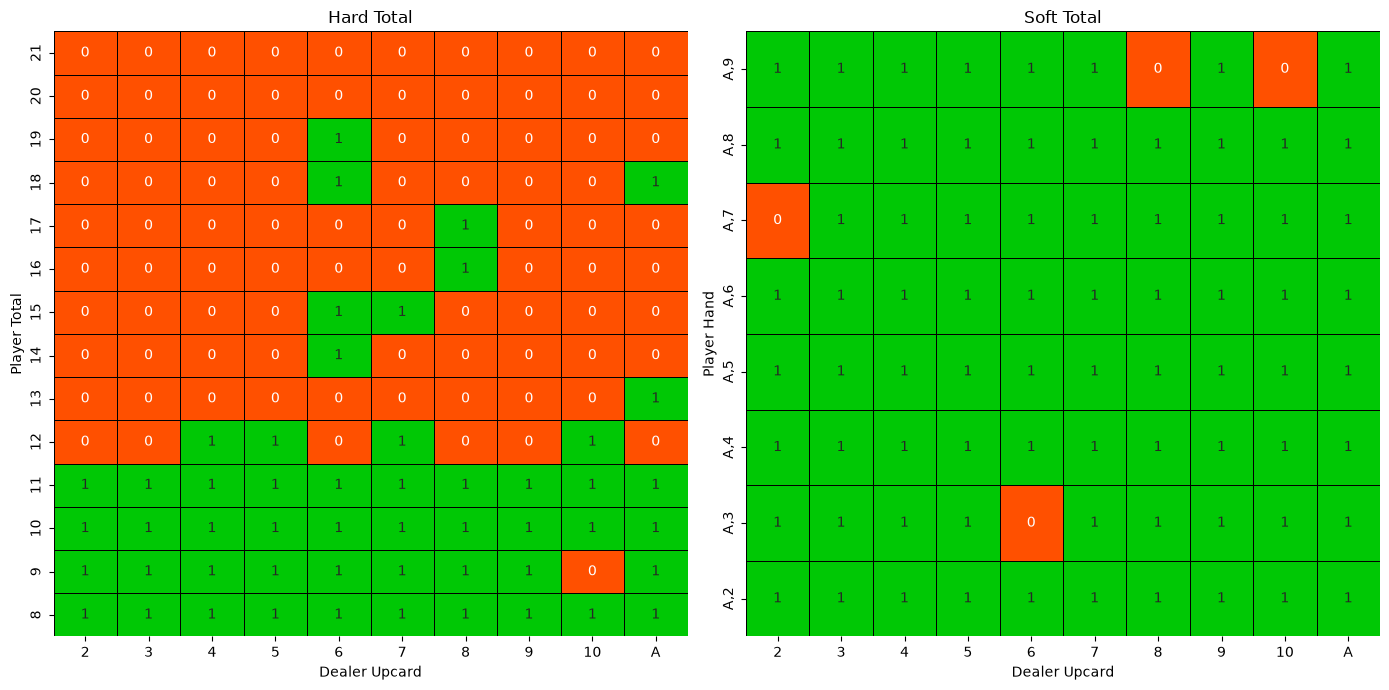

In [8]:

pink = '#FF5000' 
green = '#00C805' 
action_cmap = ListedColormap([pink, green])

dealer_upcards = [(i, str(i)) for i in range(2, 11)] + [(1, 'A')]

hard_table = []
soft_table = []
for player_sum in range(8, 22):
    pi = player_sum - 1
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        hard_table.append({
            'Player': player_sum,
            'Dealer': dealer_label,
            'Action': np.argmax(q[pi, di, 0]),
        })

for player_sum in range(13, 21):
    pi = player_sum - 1
    hand = f"A,{player_sum - 11}"
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        soft_table.append({
            'Player': hand,
            'Dealer': dealer_label,
            'Action': np.argmax(q[pi, di, 1]),
        })

col_order = [str(i) for i in range(2, 11)] + ['A']
soft_hand_order = [f"A,{i}" for i in range(9, 1, -1)]
hard_pivot = pd.DataFrame(hard_table).pivot(index='Player', columns='Dealer', values='Action')[col_order].sort_index(ascending=False)
soft_pivot = pd.DataFrame(soft_table).pivot(index='Player', columns='Dealer', values='Action')[col_order].reindex(soft_hand_order)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.heatmap(hard_pivot, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=True, fmt='d')
plt.title('Hard Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Total')

plt.subplot(1, 2, 2)
sns.heatmap(soft_pivot, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=True, fmt='d')
plt.title('Soft Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Hand')

plt.tight_layout()
plt.show()